![logo](../../figs/holberton_logo.png)

# Dog Breed Classification Using Convolutional Neural Networks


In [31]:
import tensorflow as tf

# Define the directories for training and testing data
# Replace with your own path
train_dir = '../../data/cropped/train/'
test_dir = '../../data/cropped/test/'

# Load training dataset without preprocessing
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset='training',
    batch_size=32,
    image_size=(224, 224),
    seed=123,
    shuffle=True,
)

# Load validation dataset without preprocessing
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset='validation',
    batch_size=32,
    image_size=(224, 224),
    seed=123,
)


# Load validation dataset without preprocessing
test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    batch_size=32,
    image_size=(224, 224),
    seed=42,
)

Found 12000 files belonging to 120 classes.
Using 9600 files for training.
Found 12000 files belonging to 120 classes.
Using 2400 files for validation.
Found 8580 files belonging to 120 classes.


In [32]:
# Print class names
class_names = train_ds.class_names

num_classes = len(class_names)

for class_name in class_names:
    print(class_name)

n02085620-Chihuahua
n02085782-Japanese_spaniel
n02085936-Maltese_dog
n02086079-Pekinese
n02086240-Shih-Tzu
n02086646-Blenheim_spaniel
n02086910-papillon
n02087046-toy_terrier
n02087394-Rhodesian_ridgeback
n02088094-Afghan_hound
n02088238-basset
n02088364-beagle
n02088466-bloodhound
n02088632-bluetick
n02089078-black-and-tan_coonhound
n02089867-Walker_hound
n02089973-English_foxhound
n02090379-redbone
n02090622-borzoi
n02090721-Irish_wolfhound
n02091032-Italian_greyhound
n02091134-whippet
n02091244-Ibizan_hound
n02091467-Norwegian_elkhound
n02091635-otterhound
n02091831-Saluki
n02092002-Scottish_deerhound
n02092339-Weimaraner
n02093256-Staffordshire_bullterrier
n02093428-American_Staffordshire_terrier
n02093647-Bedlington_terrier
n02093754-Border_terrier
n02093859-Kerry_blue_terrier
n02093991-Irish_terrier
n02094114-Norfolk_terrier
n02094258-Norwich_terrier
n02094433-Yorkshire_terrier
n02095314-wire-haired_fox_terrier
n02095570-Lakeland_terrier
n02095889-Sealyham_terrier
n02096051-Aired

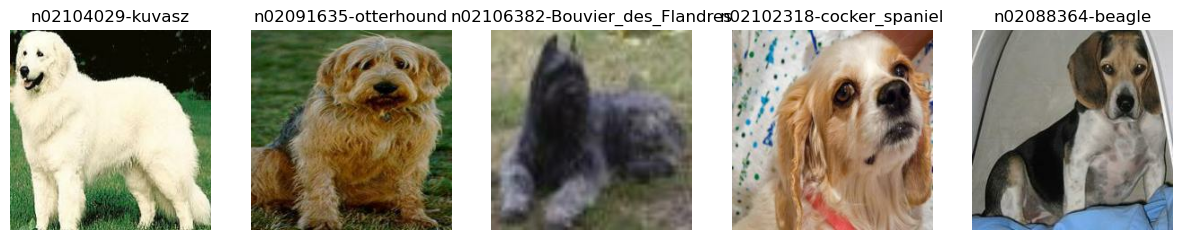

In [34]:
import matplotlib.pyplot as plt

# Load a batch of images and labels
for images, labels in train_ds.take(1):  
    batch_images = images.numpy()
    batch_labels = labels.numpy()

# Visualize the images
plt.figure(figsize=(15, 5))
for i in range(5):
    plt.subplot(1, 5, i+1)
    plt.imshow(batch_images[i].astype('uint8'))  
    plt.title(class_names[batch_labels[i]])
    plt.axis('off')
plt.show()


In [44]:
# Define the CNN model
model = models.Sequential([
    # First convolutional layer
    layers.Conv2D(32, (5, 5), activation='relu', input_shape=(224, 224, 3)),
    layers.MaxPooling2D((3, 3)),
    
    # Second convolutional layer
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((3, 3)),
    
    # Third convolutional layer
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    
    # Flatten the output of the convolutional layers
    layers.Flatten(),
    
    # Dense hidden layer
    layers.Dense(128, activation='relu'),  # Increased the number of units
    
    # Dropout layer for regularization
    layers.Dropout(0.3),  # Added dropout for regularization
    
    # Output layer
    layers.Dense(num_classes, activation='softmax')
])


In [45]:

# Compile the model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Display the model summary
model.summary()

Model: "sequential_4"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_12 (Conv2D)          (None, 220, 220, 32)      2432      
                                                                 
 max_pooling2d_12 (MaxPooli  (None, 73, 73, 32)        0         
 ng2D)                                                           
                                                                 
 conv2d_13 (Conv2D)          (None, 71, 71, 64)        18496     
                                                                 
 max_pooling2d_13 (MaxPooli  (None, 23, 23, 64)        0         
 ng2D)                                                           
                                                                 
 conv2d_14 (Conv2D)          (None, 21, 21, 128)       73856     
                                                                 
 max_pooling2d_14 (MaxPooli  (None, 10, 10, 128)      

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

# Define the EarlyStopping callback
early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

# Train the model with early stopping
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,  
    callbacks=[early_stopping]
)


Epoch 1/10
 15/300 [>.............................] - ETA: 10:16 - loss: 12.5964 - accuracy: 0.0021